In [33]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
pd.set_option("display.max_columns", 500)

EVENTS_DIR = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched"
HOURLY_DIR = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data"
SPIKES_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/all_spikes_dataset.csv"
VAULTS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vaults_list.csv"
SUPPLIERS_SHARE_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_suppliers_share.csv"
BORROWERS_SHARE_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_borrowers_share.csv"

INTERESTING_MARKETS = [
    "eth_syrupusdc_usdc",
    "eth_usr_usdc",
    "eth_rlp_usdc",
    "eth_wstusr_usdc",
    "eth_fxsave_usdc",
    "eth_siusd_usdc",
    "eth_reusd_usdc",
    "eth_siusd_usdc",
    "eth_stcusd_usdc",


    "eth_PT-RLP-4SEP2025_usdc",
    "eth_PT-USD0++-27MAR2025_usdc",
    "eth_PT-USD0++-31OCT2024_usdc",
    "eth_PT-USDe-25SEP2025_dai",
    "eth_PT-USDe-25SEP2025_usdc",
    "eth_PT-USDe-25SEP2025_usdt",
    "eth_PT-USDe-27MAR2025_dai",
    "eth_PT-USDe-27NOV2025_usds",
    "eth_PT-USDe-31JUL2025_dai",
    "eth_PT-USR-29MAY2025_usdc",
    "eth_PT-csUSDL-31JUL2025_usdc",
    "eth_PT-lvlUSD-29MAY2025_usdc",
    "eth_PT-mHYPER-20NOV2025_usdc",
    "eth_PT-reUSD-18DEC2025_usdc",
    "eth_PT-reUSD-25JUN2026_usdc",
    "eth_PT-sNUSD-5MAR2026_usdc",
    "eth_PT-sdeUSD-1753142406_usdc",
    "eth_PT-slvlUSD-25SEP2025_usdc",
    "eth_PT-slvlUSD-29MAY2025_usdc",
    "eth_PT-stcUSD-23JUL2026_usdc",
    "eth_PT-stcUSD-29JAN2026_usdc",
    "eth_PT-syrupUSDC-28AUG2025_usdc",
    "eth_PT-syrupUSDC-30OCT2025_usdc",
    "eth_PT-wstUSR-25SEP2025_usdc",
    "eth_PT-wstUSR-27MAR2025_usdc",
    "eth_PT-wstUSR-27MAR2025_usr",
]

UTILIZATION_DELTA_THRESHOLD = 0.01

def load_spikes_dataset(path):
    df = pd.read_csv(path)
    df['spike_trigger_datetime'] = pd.to_datetime(df['spike_trigger_datetime'])
    df['spike_recovery_datetime'] = pd.to_datetime(df['spike_recovery_datetime'])
    df['spike_start_ts'] = df['spike_trigger_datetime'].astype(int) // 10**9
    df['spike_end_ts'] = df['spike_recovery_datetime'].astype(int) // 10**9
    return df

def load_market_events(market_name, events_dir):
    file_path = os.path.join(events_dir, f"{market_name}.csv")
    if not os.path.exists(file_path):
        return pd.DataFrame()
    df = pd.read_csv(file_path)
    df['datetime'] = pd.to_datetime(df['datetime'])
    return df.sort_values('timestamp')

def load_vaults_list(path):
    df = pd.read_csv(path)
    return set(df['address'].unique())

def load_share_data(path):
    df = pd.read_csv(path)
    df['datetime'] = pd.to_datetime(df['datetime'])
    return df.sort_values(['market', 'timestamp'])

def preprocess_events_for_market(events_df):
    if events_df.empty:
        return events_df
    events_df = events_df.copy()
    events_df['action_number'] = events_df.groupby('user_address').cumcount() + 1
    events_df['is_borrower'] = events_df['type'].isin(['MarketBorrow', 'MarketRepay', 'MarketSupplyCollateral', 'MarketSupplyCollateral']).astype(int)
    first_action = events_df.groupby('user_address')['timestamp'].min().rename('first_action_ts')
    events_df = events_df.merge(first_action, left_on='user_address', right_index=True, how='left')
    return events_df

def compute_spike_user_analytics_for_market(market_name, spikes_df, events_df, vaults_set, 
                                            suppliers_df, borrowers_df, threshold):
    market_spikes = spikes_df[spikes_df['market_name'] == market_name].copy()
    spike_meta = market_spikes[['spike_index', 'spike_duration_seconds', 'spike_magnitude_util_delta']].drop_duplicates('spike_index')
    if market_spikes.empty or events_df.empty:
        return pd.DataFrame()
    
    events_df = preprocess_events_for_market(events_df)
    
    spike_events_list = []
    for _, spike in market_spikes.iterrows():
        mask = (events_df['timestamp'] >= spike['spike_start_ts']) & \
               (events_df['timestamp'] <= spike['spike_end_ts'])
        spike_ev = events_df[mask].copy()
        if spike_ev.empty:
            continue
        spike_ev['spike_index'] = spike['spike_index']
        spike_ev['spike_start_ts'] = spike['spike_start_ts']
        spike_ev['spike_end_ts'] = spike['spike_end_ts']
        spike_events_list.append(spike_ev)
    
    if not spike_events_list:
        return pd.DataFrame()
    
    all_spike_events = pd.concat(spike_events_list, ignore_index=True)
    
    supply_withdraw_mask = all_spike_events['type'].isin(['MarketSupply', 'MarketWithdraw'])
    supply_withdraw = all_spike_events[supply_withdraw_mask].copy()
    supply_withdraw['util_delta_abs'] = (supply_withdraw['utilization_after'] - supply_withdraw['utilization_before']).abs()
    qualifying_supply = supply_withdraw[supply_withdraw['util_delta_abs'] > threshold]
    
    borrow_repay_collat_mask = all_spike_events['type'].isin(
        ['MarketBorrow', 'MarketRepay', 'MarketSupplyCollateral', 'MarketWithdrawCollateral']
    )
    qualifying_borrow = all_spike_events[borrow_repay_collat_mask].copy()
    
    qualifying_events = pd.concat([qualifying_supply, qualifying_borrow]).drop_duplicates()
    if qualifying_events.empty:
        return pd.DataFrame()
    
    user_spike_pairs = qualifying_events[['user_address', 'spike_index', 'spike_start_ts', 'spike_end_ts']].drop_duplicates()
    
    pre_state_df = pd.merge_asof(
        user_spike_pairs.sort_values('spike_start_ts'),
        events_df[['user_address', 'timestamp', 'supply_before', 'debt_before', 'ltv_before', 
                   'health_factor_before', 'collateral_before', 'collateral_value_before',
                   'action_number', 'first_action_ts', 'is_borrower']].sort_values('timestamp'),
        left_on='spike_start_ts',
        right_on='timestamp',
        by='user_address',
        direction='backward',
        allow_exact_matches=False
    )
    
    pre_state_df['time_since_first_action'] = pre_state_df['spike_start_ts'] - pre_state_df['first_action_ts']
    pre_state_df['time_since_last_action'] = pre_state_df['spike_start_ts'] - pre_state_df['timestamp']
    pre_state_df.rename(columns={
        'timestamp': 'last_action_ts',
        'action_number': 'total_actions_before'
    }, inplace=True)
    
    agg_dict = {
        'utilization_delta': ('utilization_after', lambda x: x.max() - x.min()),
        'borrow_rate_delta': ('borrow_rate_after', lambda x: x.max() - x.min()),
        'supply_rate_delta': ('supply_rate_after', lambda x: x.max() - x.min()),
        'avg_util_delta': ('utilization_after', lambda x: (x - qualifying_events.loc[x.index, 'utilization_before']).mean()),
        'avg_borrow_rate_delta': ('borrow_rate_after', lambda x: (x - qualifying_events.loc[x.index, 'borrow_rate_before']).mean()),
        'n_actions': ('timestamp', 'count'),
        'action_types': ('type', lambda x: list(x.unique()))
    }
    
    spike_agg = qualifying_events.groupby(['user_address', 'spike_index']).agg(**agg_dict).reset_index()
    
    metrics_df = pre_state_df.merge(spike_agg, on=['user_address', 'spike_index'], how='inner')
    
    metrics_df['is_vault'] = metrics_df['user_address'].isin(vaults_set)
    metrics_df['market'] = market_name
    
    share_snapshots = suppliers_df[suppliers_df['market'] == market_name][['timestamp']].drop_duplicates().sort_values('timestamp')
    if not share_snapshots.empty:
        spike_starts = metrics_df[['spike_index', 'spike_start_ts']].drop_duplicates().sort_values('spike_start_ts')
        spike_to_snapshot = pd.merge_asof(
            spike_starts,
            share_snapshots,
            left_on='spike_start_ts',
            right_on='timestamp',
            direction='backward'
        )
        spike_to_snapshot.rename(columns={'timestamp': 'snapshot_ts'}, inplace=True)
        
        suppliers_snapshot = suppliers_df[suppliers_df['market'] == market_name].merge(
            spike_to_snapshot[['spike_index', 'snapshot_ts']], 
            left_on='timestamp', 
            right_on='snapshot_ts', 
            how='inner'
        )
        suppliers_snapshot = suppliers_snapshot.sort_values(['snapshot_ts', 'share'], ascending=[True, False])
        suppliers_snapshot['supplier_rank'] = suppliers_snapshot.groupby('snapshot_ts').cumcount() + 1
        
        borrowers_snapshot = borrowers_df[borrowers_df['market'] == market_name].merge(
            spike_to_snapshot[['spike_index', 'snapshot_ts']], 
            left_on='timestamp', 
            right_on='snapshot_ts', 
            how='inner'
        )
        borrowers_snapshot = borrowers_snapshot.sort_values(['snapshot_ts', 'share'], ascending=[True, False])
        borrowers_snapshot['borrower_rank'] = borrowers_snapshot.groupby('snapshot_ts').cumcount() + 1
        
        metrics_df = metrics_df.merge(
            suppliers_snapshot[['user_address', 'spike_index', 'share', 'supplier_rank', 'hhi', 'n_active']],
            on=['user_address', 'spike_index'],
            how='left',
            suffixes=('', '_supplier')
        )
        metrics_df = metrics_df.merge(
            borrowers_snapshot[['user_address', 'spike_index', 'share', 'borrower_rank', 'hhi', 'n_active']],
            on=['user_address', 'spike_index'],
            how='left',
            suffixes=('_supplier', '_borrower')
        )
        
        metrics_df['supplier_in_top'] = ~metrics_df['supplier_rank'].isna()
        metrics_df['borrower_in_top'] = ~metrics_df['borrower_rank'].isna()
        metrics_df.rename(columns={
            'share_supplier': 'supplier_share',
            'share_borrower': 'borrower_share',
            'hhi_supplier': 'supplier_hhi',
            'n_active_supplier': 'supplier_n_active',
            'hhi_borrower': 'borrower_hhi',
            'n_active_borrower': 'borrower_n_active'
        }, inplace=True)
    else:
        for col in ['supplier_in_top', 'supplier_share', 'supplier_rank', 'supplier_hhi', 'supplier_n_active',
                    'borrower_in_top', 'borrower_share', 'borrower_rank', 'borrower_hhi', 'borrower_n_active']:
            metrics_df[col] = np.nan
    
    final_columns = [
        'market', 'spike_index', 'spike_start_ts', 'spike_end_ts', 'user_address', 'is_vault',
        'supply_before', 'debt_before', 'ltv_before', 'health_factor_before', 'collateral_before',
        'collateral_value_before', 'total_actions_before', 'first_action_ts', 'last_action_ts',
        'time_since_first_action', 'time_since_last_action', 'n_actions', 'action_types',
        'utilization_delta', 'borrow_rate_delta', 'supply_rate_delta',
        'avg_util_delta', 'avg_borrow_rate_delta',
        'supplier_in_top', 'supplier_share', 'supplier_rank', 'supplier_hhi', 'supplier_n_active',
        'borrower_in_top', 'borrower_share', 'borrower_rank', 'borrower_hhi', 'borrower_n_active', 
        'is_borrower',
    ]
    return metrics_df[final_columns].merge(spike_meta, on='spike_index', how='left')

from tqdm import tqdm_notebook
def construct_reacting_users_df():
    spikes_df = load_spikes_dataset(SPIKES_PATH)
    vaults_set = load_vaults_list(VAULTS_PATH)
    suppliers_df = load_share_data(SUPPLIERS_SHARE_PATH)
    borrowers_df = load_share_data(BORROWERS_SHARE_PATH)
    
    all_results = []
    for market in tqdm_notebook(INTERESTING_MARKETS):
        events_df = load_market_events(market, EVENTS_DIR)
        if events_df.empty:
            print(f"No events data for market {market}")
            continue
        
        market_results = compute_spike_user_analytics_for_market(
            market, spikes_df, events_df, vaults_set, suppliers_df, borrowers_df, UTILIZATION_DELTA_THRESHOLD
        )
        if not market_results.empty:
            all_results.append(market_results)
    
    if all_results:
        final_df = pd.concat(all_results, ignore_index=True)
        output_path = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/spike_user_analytics.csv"
        # final_df.to_csv(output_path, index=False)
        # print(f"Saved analytics to {output_path}")
        return final_df
    else:
        print("No results generated.")
        return pd.DataFrame()

df = construct_reacting_users_df()

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_75485/3849811693.py:248: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for market in tqdm_notebook(INTERESTING_MARKETS):


  0%|          | 0/35 [00:00<?, ?it/s]

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_75485/3849811693.py:68: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [26]:
# df['is_']
df['is_borrower'].value_counts()
df.shape

(8589, 37)

=== OVERALL BORROWER STATISTICS ===
Total user-spike observations: 13150
Observations with borrowers: 1328
Unique borrowers: 509
Unique spikes with borrowers: 309

Spike durations for borrower participation (seconds):
count      1328.000000
mean      14943.243976
std       33525.655288
min           0.000000
25%         987.000000
50%        3984.000000
75%       13884.000000
max      327348.000000
Name: spike_duration_seconds, dtype: float64

Spike magnitude (utilization delta) for borrower participation:
count    1328.000000
mean        0.073359
std         0.077338
min         0.030037
25%         0.037604
50%         0.054746
75%         0.083818
max         1.852292
Name: spike_magnitude_util_delta, dtype: float64

Borrower position stats before spike:


,supply_before,debt_before,ltv_before,health_factor_before,collateral_value_before
count,1328.000000,1.328000e+03,1.328000e+03,1328.000000,1.242000e+03
mean,-19.380885,5.609619e+06,-1.693919e+11,4.946876,7.009851e+06
std,265.504138,1.064325e+07,2.609917e+12,61.416740,1.324707e+07
min,-6779.364554,-2.154607e+05,-4.980144e+13,-0.000000,-2.793968e-09
25%,0.000000,2.484323e+04,2.417025e-04,0.872412,4.236859e+04
50%,0.000000,7.501298e+05,7.981500e-01,1.052800,1.019140e+06
75%,0.000000,4.516789e+06,8.657428e-01,1.125676,5.697148e+06
max,0.000000,9.284057e+07,9.873973e-01,1000.000000,1.553088e+08



Top share flags:
Borrowers in top suppliers: 817 (61.52%)
Borrowers in top borrowers: 798 (60.09%)

=== MARKET-LEVEL STATISTICS ===


,market,total_spikes,spikes_with_borrowers,spikes_without_borrowers,pct_spikes_with_borrowers,avg_duration_sec,avg_duration_sec_borrowers,avg_magnitude,avg_magnitude_borrowers,unique_borrowers
0,eth_syrupusdc_usdc,681,39,642,5.726872,2158.835294,6373.866667,0.077188,0.066246,33
1,eth_usr_usdc,384,71,313,18.489583,2676.700389,6196.844037,0.064823,0.057725,82
2,eth_rlp_usdc,767,133,634,17.340287,6498.501114,17198.372093,0.068715,0.072100,76
3,eth_wstusr_usdc,869,66,803,7.594937,6271.799659,18510.086957,0.281387,0.122789,38
4,eth_fxsave_usdc,370,51,319,13.783784,6606.298507,8875.471698,0.095740,0.074357,13
5,eth_siusd_usdc,122,32,90,26.229508,6196.071429,9349.838710,0.051963,0.052764,14
6,eth_reusd_usdc,187,8,179,4.278075,8674.537396,22848.000000,0.075347,0.056433,5
7,eth_stcusd_usdc,305,18,287,5.901639,3199.193133,6618.315789,0.073878,0.068676,9
8,eth_PT-RLP-4SEP2025_usdc,167,29,138,17.365269,7012.422857,7602.375000,0.110065,0.105376,13
9,eth_PT-USD0++-27MAR2025_usdc,96,36,60,37.500000,7003.212435,7464.571429,0.080568,0.071658,15


/Users/yegortrussov/Library/Python/3.9/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


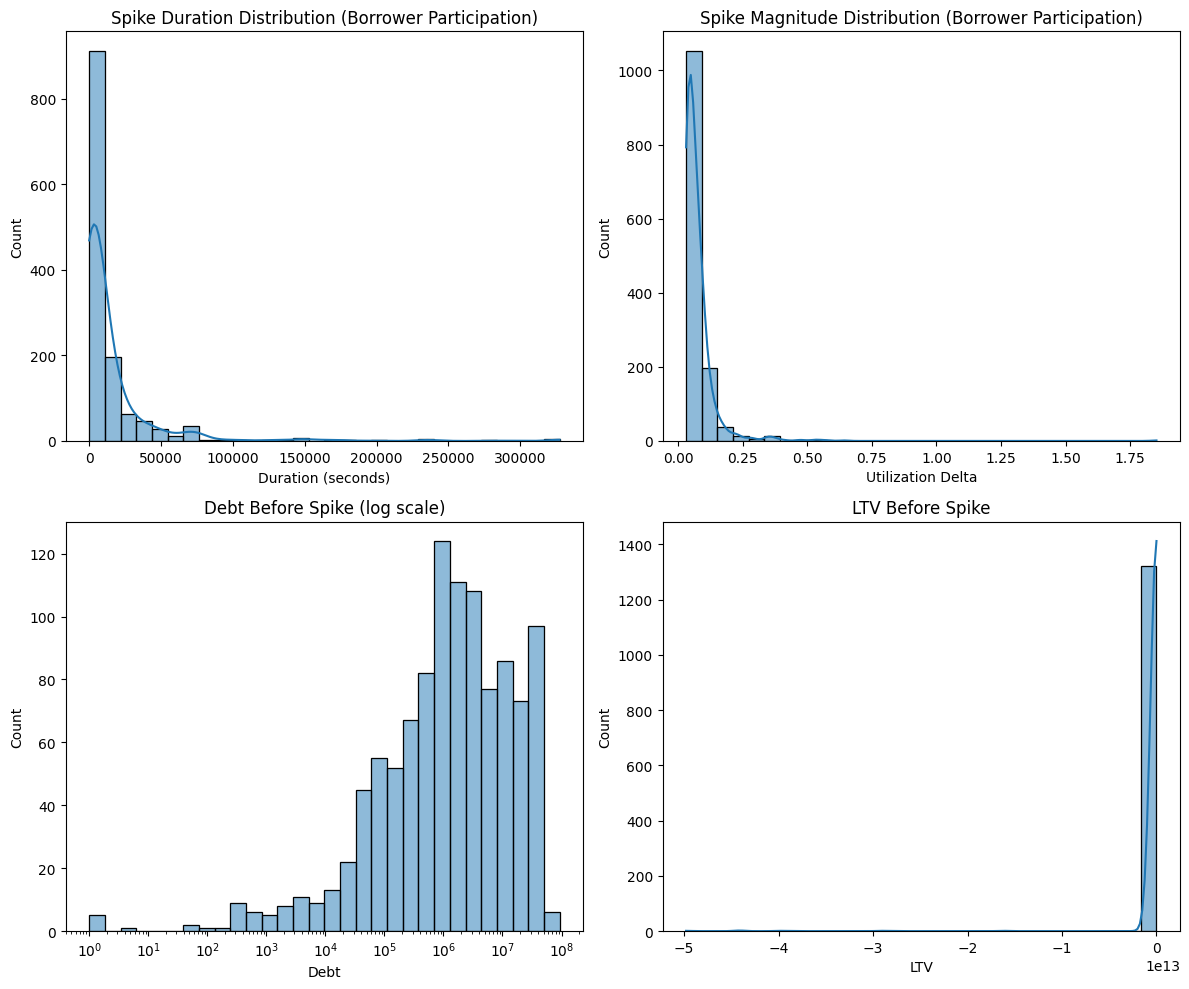


Plots saved to borrower_analysis_plots.png


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/spike_user_analytics.csv"

def load_analytics(path):
    return pd.read_csv(path)

def overall_stats(df):
    borrower_df = df[df['is_borrower'] == 1]
    if borrower_df.empty:
        print("No borrowers found.")
        return
    
    print("=== OVERALL BORROWER STATISTICS ===")
    print(f"Total user-spike observations: {len(df)}")
    print(f"Observations with borrowers: {len(borrower_df)}")
    print(f"Unique borrowers: {borrower_df['user_address'].nunique()}")
    print(f"Unique spikes with borrowers: {borrower_df['spike_index'].nunique()}")
    
    duration_stats = borrower_df['spike_duration_seconds'].describe()
    magnitude_stats = borrower_df['spike_magnitude_util_delta'].describe()
    
    print("\nSpike durations for borrower participation (seconds):")
    print(duration_stats)
    print("\nSpike magnitude (utilization delta) for borrower participation:")
    print(magnitude_stats)
    
    print("\nBorrower position stats before spike:")
    pos_cols = ['supply_before', 'debt_before', 'ltv_before', 'health_factor_before', 'collateral_value_before']
    display(borrower_df[pos_cols].describe())
    
    print("\nTop share flags:")
    print(f"Borrowers in top suppliers: {borrower_df['supplier_in_top'].sum()} ({borrower_df['supplier_in_top'].mean():.2%})")
    print(f"Borrowers in top borrowers: {borrower_df['borrower_in_top'].sum()} ({borrower_df['borrower_in_top'].mean():.2%})")

def market_level_stats(df):
    market_summary = []
    for market in df['market'].unique():
        market_df = df[df['market'] == market]
        total_spikes = market_df['spike_index'].nunique()
        spikes_with_borrowers = market_df[market_df['is_borrower'] == 1]['spike_index'].nunique()
        spikes_without_borrowers = total_spikes - spikes_with_borrowers
        
        borrower_market = market_df[market_df['is_borrower'] == 1]
        avg_duration = borrower_market['spike_duration_seconds'].mean() if not borrower_market.empty else np.nan
        avg_magnitude = borrower_market['spike_magnitude_util_delta'].mean() if not borrower_market.empty else np.nan
        
        market_summary.append({
            'market': market,
            'total_spikes': total_spikes,
            'spikes_with_borrowers': spikes_with_borrowers,
            'spikes_without_borrowers': spikes_without_borrowers,
            'pct_spikes_with_borrowers': spikes_with_borrowers / total_spikes * 100 if total_spikes > 0 else 0,
            'avg_duration_sec': market_df['spike_duration_seconds'].mean(),
            'avg_duration_sec_borrowers': avg_duration,
            'avg_magnitude': market_df['spike_magnitude_util_delta'].mean(),
            'avg_magnitude_borrowers': avg_magnitude,
            'unique_borrowers': borrower_market['user_address'].nunique(),
        })
    
    summary_df = pd.DataFrame(market_summary)
    print("\n=== MARKET-LEVEL STATISTICS ===")
    display(summary_df)
    return summary_df

def plot_distributions(df):
    borrower_df = df[df['is_borrower'] == 1]
    if borrower_df.empty:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    sns.histplot(borrower_df['spike_duration_seconds'], bins=30, kde=True, ax=axes[0,0])
    axes[0,0].set_title('Spike Duration Distribution (Borrower Participation)')
    axes[0,0].set_xlabel('Duration (seconds)')
    
    sns.histplot(borrower_df['spike_magnitude_util_delta'], bins=30, kde=True, ax=axes[0,1])
    axes[0,1].set_title('Spike Magnitude Distribution (Borrower Participation)')
    axes[0,1].set_xlabel('Utilization Delta')
    
    sns.histplot(borrower_df['debt_before'], bins=30, log_scale=True, kde=True, ax=axes[1,0])
    axes[1,0].set_title('Debt Before Spike (log scale)')
    axes[1,0].set_xlabel('Debt')
    
    sns.histplot(borrower_df['ltv_before'].dropna(), bins=30, kde=True, ax=axes[1,1])
    axes[1,1].set_title('LTV Before Spike')
    axes[1,1].set_xlabel('LTV')
    
    plt.tight_layout()
    plt.show()
    print("\nPlots saved to borrower_analysis_plots.png")

if __name__ == "__main__":
    df['is_borrower'] = df['is_borrower'].fillna(0).astype(int)
    
    overall_stats(df)
    market_summary = market_level_stats(df)
    plot_distributions(df)


<Axes: xlabel='spike_duration_seconds', ylabel='Density'>

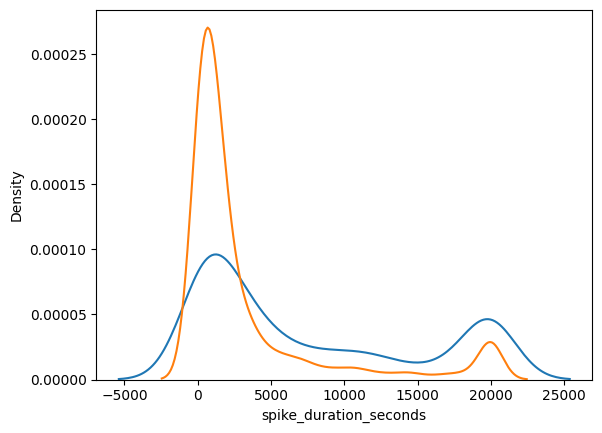

In [38]:
sns.kdeplot(
    df[df["is_borrower"] == 1]["spike_duration_seconds"].clip(0,20_000)
)
sns.kdeplot(
    df[df["is_borrower"] == 0]["spike_duration_seconds"].clip(0,20_000)
)

In [35]:
df

,market,spike_index,spike_start_ts,spike_end_ts,user_address,is_vault,supply_before,debt_before,ltv_before,health_factor_before,collateral_before,collateral_value_before,total_actions_before,first_action_ts,last_action_ts,time_since_first_action,time_since_last_action,n_actions,action_types,utilization_delta,borrow_rate_delta,supply_rate_delta,avg_util_delta,avg_borrow_rate_delta,supplier_in_top,supplier_share,supplier_rank,supplier_hhi,supplier_n_active,borrower_in_top,borrower_share,borrower_rank,borrower_hhi,borrower_n_active,is_borrower,spike_duration_seconds,spike_magnitude_util_delta
0,eth_syrupusdc_usdc,0,1743071591,1743079895,0x37C854b29bD786da3EaE78AFE409165C4Cc85156,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,[MarketSupply],0.000000,0.000000,0.000000,-1.547502e-02,-0.033063,False,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,0,8304,0.235663
1,eth_syrupusdc_usdc,0,1743071591,1743079895,0xeb93e6fc46B78C19bFE3264afabCcae410956389,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,"[MarketBorrow, MarketSupplyCollateral]",0.000000,0.000000,0.000000,2.356634e-01,0.221705,True,27.402456,2.0,0.190993,17.0,True,23.569735,2.0,0.188138,17.0,0,8304,0.235663
2,eth_syrupusdc_usdc,0,1743071591,1743079895,0xc582F04d8a82795aa2Ff9c8bb4c1c889fe7b754e,True,4.654577e+06,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,107.0,1.742924e+09,1.743071e+09,147888.0,936.0,1,[MarketSupply],0.000000,0.000000,0.000000,-8.878327e-02,-0.125728,False,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,0,8304,0.235663
3,eth_syrupusdc_usdc,1,1743090455,1743096023,0xc582F04d8a82795aa2Ff9c8bb4c1c889fe7b754e,True,5.470332e+06,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,142.0,1.742924e+09,1.743090e+09,166752.0,444.0,3,[MarketSupply],0.069052,0.148437,0.153122,-2.102740e-02,-0.045422,False,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,0,5568,0.160182
4,eth_syrupusdc_usdc,1,1743090455,1743096023,0xfa95f3EA483Ca6a60C72E868a0404e6d0a031d6b,False,0.000000e+00,2.189768e+05,0.870125,1.051796,2.311185e+05,2.516880e+05,23.0,1.742986e+09,1.742997e+09,104760.0,93288.0,15,"[MarketWithdrawCollateral, MarketRepay]",0.060604,0.118465,0.117531,-4.001782e-03,-0.007071,False,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,1,5568,0.160182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13145,eth_PT-wstUSR-27MAR2025_usr,34,1742641451,1742749283,0xD50DA5F859811A91fD1876C9461fD39c23C747Ad,True,1.411633e+07,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,113.0,1.738877e+09,1.742635e+09,3764004.0,6084.0,1,[MarketWithdraw],0.000000,0.000000,0.000000,1.228015e-01,0.095017,False,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,0,107832,0.122801
13146,eth_PT-wstUSR-27MAR2025_usr,34,1742641451,1742749283,0x7a26967Bba9EEf027f7484a194BF19994Eb12831,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,"[MarketSupplyCollateral, MarketBorrow, MarketR...",0.022782,0.029564,0.032908,1.158789e-07,-0.000079,False,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,0,107832,0.122801
13147,eth_PT-wstUSR-27MAR2025_usr,35,1742816159,1742818055,0x7a26967Bba9EEf027f7484a194BF19994Eb12831,False,0.000000e+00,3.163203e+05,0.791619,1.155859,4.000000e+05,3.995864e+05,4.0,1.742729e+09,1.742732e+09,87120.0,84564.0,4,"[MarketBorrow, MarketSupplyCollateral, MarketR...",0.120454,0.137176,0.142575,2.210014e-06,-0.000152,True,11.492628,4.0,0.169119,43.0,True,12.070592,4.0,0.177737,39.0,0,1896,0.120458
13148,eth_PT-wstUSR-27MAR2025_usr,36,1742901383,1742905043,0x7a26967Bba9EEf027f7484a194BF19994Eb12831,False,0.000000e+00,1.678378e+06,0.000000,0.000000,2.003498e+06,NaN,8.0,1.742729e+09,1.742818e+09,172344.0,83328.0,6,"[MarketSupplyCollateral, MarketBorrow, MarketW...",0.143775,0.137612,0.143923,1.726667e-04,0.001449,True,13.236916,4.0,0.173751,42.0,True,14.093549,4.0,0.182766,37.0,0,3660,0.140612
